# Stereographic maps
This notebook showcases an accessor class for stereographic map plots produced with `cartopy` and `matplotlib`.

<!-- 
<div class='alert alert-success'>
This notebook showcases an accessor class for stereographic map plots produced with `cartopy` and `matplotlib`.
</div> -->

An accessor can be registered with the `register_geoaxes_accessor` decorator in `my_code_base.plot.map_plots`. The accessor can be given an arbitrary name and should inherit from the `my_code_base.plot.map_plots.GeoAxesAccessor` ABC meta class, which provides some basic geographic-map related methods. 

For example, the "polar" accessor is registered as follows:

```python
@register_geoaxes_accessor("polar")
class StereographicAxisAccessor(GeoAxesAccessor):
    """An accessor to handle features and finishing of stereographic plots produced with `cartopy`.
    Can handle both :class:`ccrs.NorthPolarStereo` and :class:`ccrs.SouthPolarStereo` projections."""
    def __init__(self, ax):
        super().__init__(ax)

        ...

```

The following shall show the usage of such an accessor.

<div class="alert alert-success">
    <b>Tip:</b><br>
This accessor works both for `projection=cartopy.crs.NorthPolarStereo()` and `projection=cartopy.crs.SouthPolarStereo()`.
</div>

First, let's load some packages. The "polar" accessor is part of `my_code_base.plot`.

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from my_code_base.plot.maps import *

Features can be added, for example, with the method `add_features`, which adds the most common features to the axis, including a ruler around the domain.

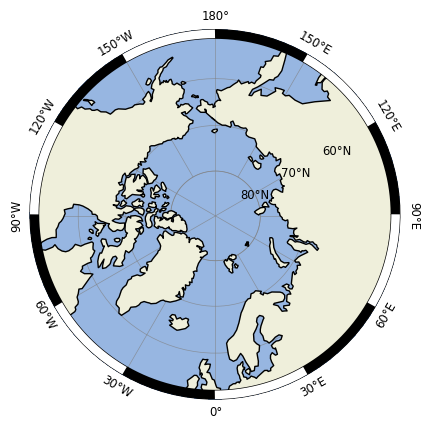

In [2]:
ax = plt.subplot(projection=ccrs.NorthPolarStereo())

ax.polar.add_features(ruler_kwargs={'segment_length':30})

Alternatively, the different features can be added individually:

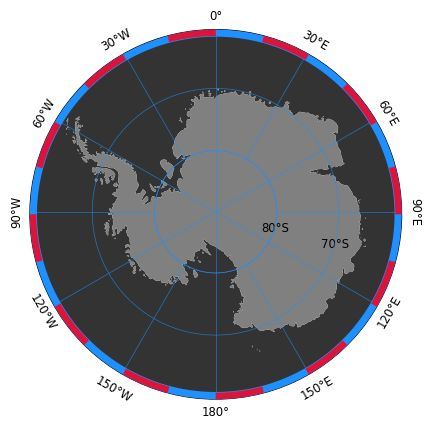

In [5]:
ax = plt.subplot(projection=ccrs.SouthPolarStereo())

ax.polar.set_extent([-180,180,-90,-60])
ax.polar.add_ocean(fc='.2')
ax.polar.add_land(fc='.5')
ax.polar.make_circular()
ax.polar.add_gridlines(zorder=100, color='dodgerblue')
ax.polar.rotate_lon_labels()
ax.polar.rotate_lat_labels(target_lon=105)
ax.polar.add_ruler(segment_length=15, primary_color='dodgerblue', secondary_color='crimson')

More details about the individual arguments for each method can be found in the source code of `my_code_base.plot.maps.StereographicAxisAccessor`.